# **3장 : 평가**
# **3.1 정확도(Accuracy)**
# **3.2 오차 행렬**
# **3.3 정밀도와 재현율**
# **3.4 F1 Score**
# **3.5 ROC 곡선과 AUC**

# 평가

분류의 성능 평가 지표  
1. 정확도
2. 오차행렬
3. 정밀도
4. 재현률
5. F1 Score
6. ROC AUC    
  
분류는 이진 분류와 멀티 분류로 나눌 수 있는데, 위 방법은 특히 이진 분류에 많이 쓰임  

## 정확도  
Accuracy = 예측 결과가 동일한 데이터 건수 / 전체 예측 데이터 건수

In [1]:
from sklearn.base import BaseEstimator

class myDummyClassifier(BaseEstimator):
    # fit 메서드는 아무것도 학습하지 않음
    def fit(self,X,y=None):
        pass
    # predict 메서드는 단순히 Sex feature가 1이면 0, 그렇지 않으면 1로 예측
    def predict(self,X):
        pred = np.zeros((X.shape[0],1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i]==1:
                pred[i]=0
            else:
                pred[i]=1
        return pred

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from common.functions import transform_features

titanic_df = pd.read_csv('./train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived',axis=1) # 열 단위 삭제
X_titanic_df = transform_features(X_titanic_df) # 전처리 함수 transform_features 적용 (결측치 처리, 불필요한 열 제거, one-hot-encoding등 수행)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=0)

myclf = myDummyClassifier()
myclf.fit(X_train,y_train)

mypredictions = myclf.predict(X_test)
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test,mypredictions))) 

Dummy Classifier의 정확도는: 0.7877


**MNIST 데이터셋**  
0부터 9까지 숫자 이미지 분류  
레이블 값이 7인 것만 True, 나머지를 False로 변환해 이진 분류 문제로 바꿈

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass
    # X의 길이만큼 matrix 생성, 값은 모두 0(False)로
    def predict(self,X):
        return np.zeros((len(X),1), dtype = bool)

digits = load_digits()

# digits 번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환
y = (digits.target==7).astype(int)
X_train,X_test,y_train,y_test = train_test_split(digits.data,y,random_state=11)

In [8]:
# 불균형한 레이블 데이터 분포도 확인
print("레이블 테스트 세트 크기 : ", y_test.shape)
print("테스트 세트 레이블 0과 1의 분포도")
print(pd.Series(y_test).value_counts())

# 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print("모든 예측을 0으로 하여도 정확도는: {:.3f}".format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기 :  (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는: 0.900


**이처럼 편향된 데이터셋에서는 Accuracy를 성능 수치로 사용해서는 안된다.**  
**모든 예측을 0으로 해도 90%가 나오기 때문이다. (실제로 클래스 1은 전혀 맞추지 못해도 이렇게 나온다)**

## 오차 행렬 (confusion)
TP : 예측값 Positive(1), 실제값 Positive(1)    
FP : 예측값 Positive(1), 실제값 Negative(0)  
FN : 예측값 Negative(0), 실제값 Positive(1)  
TN : 예측값 Negative(0), 실제값 Negative(0)  

In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,fakepred)

array([[405,   0],
       [ 45,   0]], dtype=int64)

TN FP  
FN TP

### 이거면 정확도(Accuracy), 정밀도(Precision), 재현율(Recall) 모두 알 수 있다!!  
## Accuracy = 예측 결과와 실제 값이 동일한 건수 / 전체 데이터 수 = (TN+TP) / (전체)
## Precision = 예측 +실제 Positive / 예측 Positive = TP / (TP + FP)
## Recall = 예측 +실제 Positive / 실제 Positive = TP / (TP + FN)
Recall 같은 경우에는 실제 Positive를 Negative로 판단하면 큰일나는 경우에 중요하다.  
예) 암 환자같은 경우 양성을 음성이라고 판단하면 사람 죽음  
Precision 같은 경우에는 실제 Negative를 Positive으로 판단하면 큰일나는 경우에 중요하다.  
예) 스팸 메일을 분류할 때 스펨 메일(Positive)를 일반 메일(Negative)로 분류해도 불편함 없지만 반대는 아예 메일을 받지 못한다.  
이 두 가지 지표 모두 높도록 만들어야 이상적임

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test,pred):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    print('Accuracy: {0:.4f}, Precision: {1:.4f}, Recall: {2:.4f}'.format(accuracy,precision,recall))

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from common.functions import transform_features
from sklearn.linear_model import LogisticRegression

titanic_df = pd.read_csv('./train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived',axis=1) # 열 단위 삭제
X_titanic_df = transform_features(X_titanic_df) # 전처리 함수 transform_features 적용 (결측치 처리, 불필요한 열 제거, one-hot-encoding등 수행)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=11)

Ir_clf = LogisticRegression(solver = 'liblinear') # 로지스틱 회귀의 최적의 알고리즘 유형 지정 (보통은 Ibfgs이다)
Ir_clf.fit(X_train,y_train)
pred = Ir_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[108  10]
 [ 14  47]]
Accuracy: 0.8659, Precision: 0.8246, Recall: 0.7705


## Precision / Recall Trade-off
정밀도 또는 재현율이 겁나 중요한 경후 분류의 결정 임계값(threshold)를 조정해 이 둘의 수치를 높일 수 있음.  
보통 정밀도가 높아지면 재현율이 떨어지고, 재현률이 높아지면 정밀도가 떨어짐 (상호 보완적인 평가 지표) 
일반적으로 이진 분류에서는 임계값을 50%로 설정하고 이보다 확률이 크면 Positive, 작으면 Negative  
예) 특정 데이터가 0이 될 확률 10%, 1이 될 확률 90%라고 예측 = 1이라로 예측  

**predict_proba(X) 메서드**  
X: 예측하고자 하는 입력 데이터  
반환값: (샘플 수, 클래스 수) 형태의 2차원 배열  
각 행은 해당 샘플이 각 클래스에 속할 확률을 나타냄.  
예) array([[0.8, 0.2],[0.3, 0.7],[0.6, 0.4]])  
두 번째 샘플은 클래스 1일 확률이 더 높으므로 predict() 하면 1로 분류됨

In [18]:
pred_proba = Ir_clf.predict_proba(X_test)
pred = Ir_clf.predict(X_test)
print('pred_proba 결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출: \n', pred_proba[:3])

# 예측 확률 array와 예측 결괏값 array를 병함(concatenate)해 예측 확률과 결괏값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1,1)],axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측\n', pred_proba_result[:3])

pred_proba 결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출: 
 [[0.44935227 0.55064773]
 [0.86335512 0.13664488]
 [0.86429645 0.13570355]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측
 [[0.44935227 0.55064773 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429645 0.13570355 0.        ]]


### Binarizer : 분류 결정 임계값을 조절해 정밀도와 재현율 성능 수치 상호 보완적으로 조절 가능

In [21]:
from sklearn.preprocessing import Binarizer

X=[[1,-1,2],[2,0,0],[0,1.1,1.2]]

binarizer = Binarizer(threshold = 1.1)
print(binarizer.fit_transform(X))
# fit(X) : X에서 무언가를 학습, 여기에서는 그냥 threshold 기준이기 때문에 아무것도 안함
# transform(X) : X의 모든 원소를 threshold와 비교해서 x > threshold 면 1.0, 아니면 0.0

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [20]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.5

# predict_proba의 두 번째 열인 positive 클래스 열 하나만 추출 해 Binarizer 적용
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
Accuracy: 0.8659, Precision: 0.8246, Recall: 0.7705


In [22]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.4

# predict_proba의 두 번째 열인 positive 클래스 열 하나만 추출 해 Binarizer 적용
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[97 21]
 [11 50]]
Accuracy: 0.8212, Precision: 0.7042, Recall: 0.8197


당연히 threshold가 0.5보다 0.4일 때가 재현율이 올라가고 정밀도는 떨어짐.  
0.4일 때가 positive로 더 예측 잘하기 때문이다.  
Precision = 예측 + 실제 Positive / 예측 Positive = TP / (TP + FP)  
Recall = 예측 + 실제 Positive / 실제 Positive = TP / (TP + FN)  
여기에서 positive 예측값이 올라가기 때문에 recall은 늘어나고, precision은 일반적으로 줄어들음  

In [31]:
thresholds = [0.4,0.45,0.5,0.55,0.6]

def get_eval_by_threshold(y_test,pred_proba_c1,thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임계값:', custom_threshold)
        get_clf_eval(y_test,custom_predict)
        print('\n\n')

get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임계값: 0.4
오차 행렬
[[97 21]
 [11 50]]
Accuracy: 0.8212, Precision: 0.7042, Recall: 0.8197, F1 score : 0.7576



임계값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
Accuracy: 0.8547, Precision: 0.7869, Recall: 0.7869, F1 score : 0.7869



임계값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
Accuracy: 0.8659, Precision: 0.8246, Recall: 0.7705, F1 score : 0.7966



임계값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
Accuracy: 0.8715, Precision: 0.8654, Recall: 0.7377, F1 score : 0.7965



임계값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
Accuracy: 0.8771, Precision: 0.8980, Recall: 0.7213, F1 score : 0.8000





**precision_recall_curve : 0.11~0.95 정도의 임계값을 담은 ndarray와 이 임곗값에 해당하는 정밀도 및 재현율 값을 담은 ndarray반환**

In [26]:
from sklearn.metrics import precision_recall_curve

pred_proba_class1 = Ir_clf.predict_proba(X_test)[:,1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test,pred_proba_class1)
print('반환된 분류 결정 입곗값 배열의 shape:', thresholds.shape)

# 반환된 임계값 배열 row가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 step으로 추출
thr_index = np.arange(0,thresholds.shape[0],15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index],2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도 : ',np.round(precisions[thr_index],3))
print('샘플 임계값별 재현율 : ',np.round(recalls[thr_index],3))

반환된 분류 결정 입곗값 배열의 shape: (165,)
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도 :  [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율 :  [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


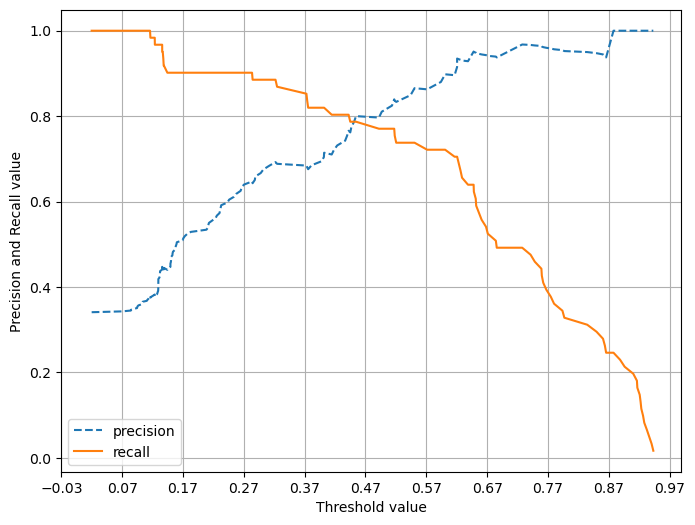

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test,pred_proba_c1):
    precisions, recalls, thresholds = precision_recall_curve(y_test,pred_proba_class1)

    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary],linestyle='--',label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label = 'recall')

    # threshold 값 x축의 scale을 0.1단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))

    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(y_test,Ir_clf.predict_proba(X_test)[:,1])

정밀도 100% 되는 방법 : 확실한 기준만 positive로 분류하기 (암 판별할 때 종양 크기가 거의 사람 죽을 정도인 사람만 암으로 판별)  
재현율 100% 되는 방법 : positive 기준 낮춰서 다 positive로 예측하기  
그래서 이 두개가 균형을 맞아야 함.  

## F1 Score
## F1 = 2 / ((1/Recall) + (1/Precision)) = 2*(precision*recall) / (precision+recall)
정밀도와 재현율을 결합한 지표. 정밀도와 재현율 중 어느 한 쪽으로 치우치지 않을 때 상대적으로 높은 값을 가짐

In [29]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,pred)
print('F1 score: {0:.4f}'.format(f1))

F1 score: 0.7966


In [32]:
def get_clf_eval(y_test,pred):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    print('Accuracy: {0:.4f}, Precision: {1:.4f}, Recall: {2:.4f}, F1 score : {3:.4f}'.format(accuracy,precision,recall,f1))

thresholds = [0.4,0.45,0.5,0.55,0.60]
pred_proba = Ir_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임계값: 0.4
오차 행렬
[[97 21]
 [11 50]]
Accuracy: 0.8212, Precision: 0.7042, Recall: 0.8197, F1 score : 0.7576



임계값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
Accuracy: 0.8547, Precision: 0.7869, Recall: 0.7869, F1 score : 0.7869



임계값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
Accuracy: 0.8659, Precision: 0.8246, Recall: 0.7705, F1 score : 0.7966



임계값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
Accuracy: 0.8715, Precision: 0.8654, Recall: 0.7377, F1 score : 0.7965



임계값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
Accuracy: 0.8771, Precision: 0.8980, Recall: 0.7213, F1 score : 0.8000





## ROC곡선과 AUC Score
  
### 평가 지표
1. 정확도(Accuracy) = 예측 결과와 실제 값이 동일한 건수 / 전체 데이터 수 = (TN+TP) / (전체)  
2. 정밀도(Precision) = 예측+실제 Positive / 예측 Positive = TP / (TP + FP)  
3. 재현율,민감도(Recall=TPR) = 예측+실제 Positive / 실제 Positive = TP / (TP + FN)  
4. 특이도(Specificity=TNR) = 예측+실제 Negative / 실제 Negative = TN / (TN + FP)  
TPR : True Positive Rate, TNR : True Negative Rate  
**FPR : False Positive Rate = 1-TNR = FP / (FP + TN)**  
  
### ROC곡선
True Positive Rate(TPR)과 False Positive Rate(FPR) 의 관계를 시각화한 그래프.  
x축: FPR = 1-특이도  
y축: TPR = 재현율  
모델이 출력하는 분류 확률의 임계값을 0부터 1까지 변화시키면서, 각 임계값마다 계산된 (FPR, TPR) 쌍을 그래프로 나타낸 것이다.  
(0,1) 점은 완벽한 분류기를 의미한다 (FPR = 0, TPR = 1)
  
### AUC Score
ROC 곡선 아래 면적을 의미, 모델의 전반적인 분류 성능을 하나의 수치로 표현해줌
범위: 0 ≤ AUC ≤ 1  
AUC = 1.0: 완벽한 모델  
AUC = 0.5: 랜덤 추측과 동일 (무작위 분류기)  
AUC < 0.5: 분류 결과가 오히려 반대로 예측됨 (모델이 나쁨)  
AUC는 임의로 선택된 양성 샘플이 음성 샘플보다 더 높은 확률로 분류될 확률을 의미한다.  

## roc_curve()
입력 : y_true(실제 클래스 값 array), y_score(predict_proba의 반환 값 array에서 positive column의 예측 확률)  
출력 : fpr, tpr, thresholds  

In [35]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일 때의 예측 확률 추출
pred_proba_class1= Ir_clf.predict_proba(X_test)[:,1]

fprs,tprs,thresholds = roc_curve(y_test,pred_proba_class1)
# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출
# Thresholds[0]은 max(예측확률)+1로 임의 설정되므로 이를 제외하기 위헤 np.arange는 1부터 시작
thr_index = np.arange(1,thresholds.shape[0],5)

print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값: ',np.round(thresholds[thr_index],2))

print('샘플 입곗값별 FPR: ',np.round(fprs[thr_index],3))
print('샘플 입곗값별 TPR: ',np.round(tprs[thr_index],3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값:  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 입곗값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 입곗값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


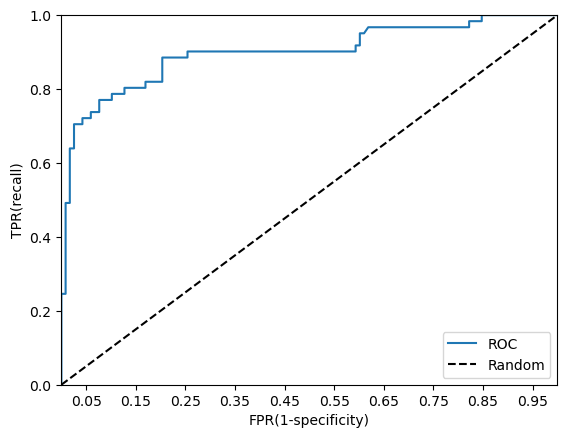

In [36]:
def roc_curve_plot(y_test,pred_proba_c1):
    fprs,tprs,thresholds = roc_curve(y_test,pred_proba_class1)
    plt.plot(fprs,tprs,label='ROC')
    plt.plot([0,1],[0,1],'k--',label='Random')

    start,end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel('FPR(1-specificity)')
    plt.ylabel('TPR(recall)')
    plt.legend()
    plt.show()

roc_curve_plot(y_test,pred_proba[:,1])

In [37]:
from sklearn.metrics import roc_auc_score

pred_proba = Ir_clf.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test,pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [41]:
def get_clf_eval(y_test,pred):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    roc_auc = roc_auc_score(y_test,pred_proba)
    print('오차 행렬')
    print(confusion)
    print('Accuracy: {0:.4f}, Precision: {1:.4f}, Recall: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))